In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
models = ['Naive Bayes', 'SVM', 'Logistic Regression']

accuracy = [0.6, 0.55, 0.6]  
precision = [0.636, 0.519, 0.750]
recall = [0.6, 0.55, 0.6]
f1 = [0.573, 0.503, 0.532]

In [3]:
results_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.60,0.636,0.60,0.573
1,SVM,0.55,0.519,0.55,0.503
2,Logistic Regression,0.60,0.750,0.60,0.532


## Accuracy comparison of models

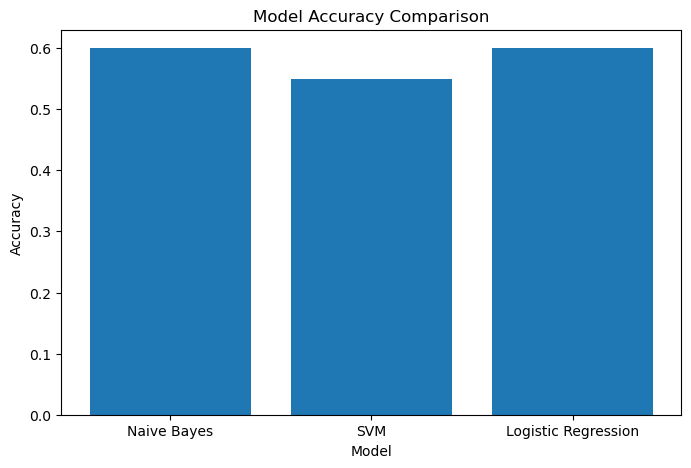

In [5]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.savefig("../visuals/11_accuracy_comparison.png")
plt.show()

## F1 Score comparison of Models

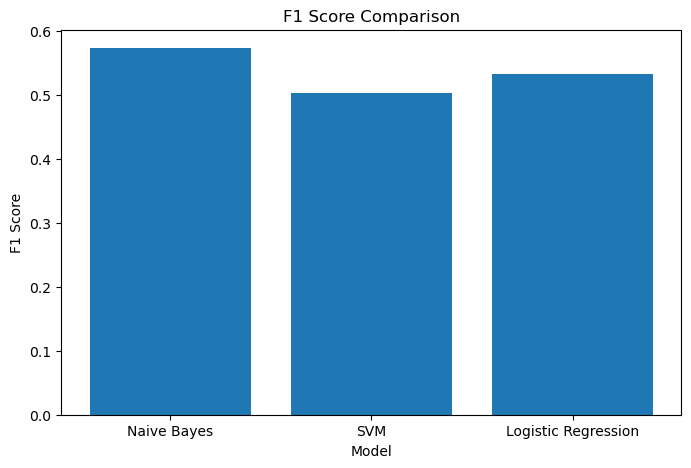

In [7]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['F1 Score'])

plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.savefig("../visuals/12_f1_comparison.png")
plt.show()

## Precision Score Comparison

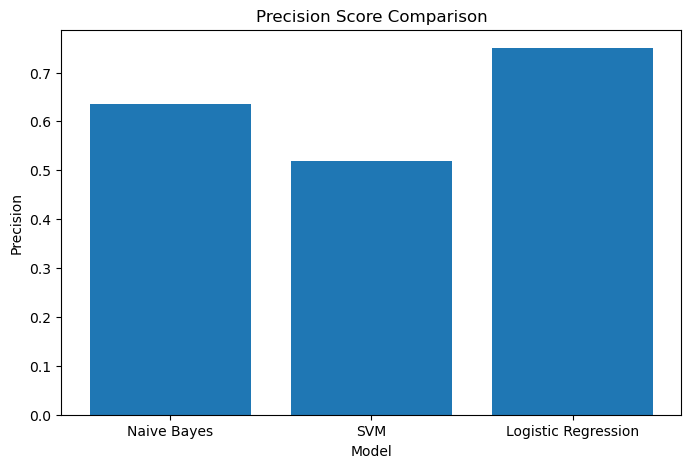

In [9]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Precision'])

plt.title("Precision Score Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.savefig("../visuals/13_precision_comparison.png")
plt.show()

## Comparison of all metrics using Bar Chart

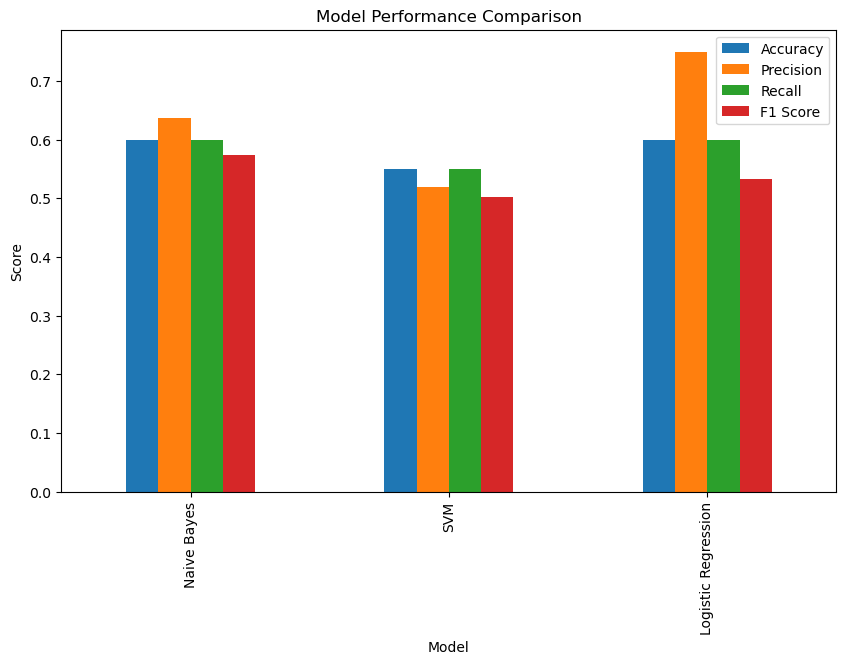

In [11]:
results_df.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.savefig("../visuals/14_all_metrics_comparison.png")
plt.show()

## Identifying Best Model

In [13]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("Best Model Based on Accuracy:")
print(best_model)

Best Model Based on Accuracy:
Model        Naive Bayes
Accuracy             0.6
Precision          0.636
Recall               0.6
F1 Score           0.573
Name: 0, dtype: object


In [14]:
best_model = results_df.loc[results_df['F1 Score'].idxmax()]

print("Best Model Based on F1 Score:")
print(best_model)

Best Model Based on F1 Score:
Model        Naive Bayes
Accuracy             0.6
Precision          0.636
Recall               0.6
F1 Score           0.573
Name: 0, dtype: object


In [15]:
print("Since accuracy of Naive Bayes Model and Logistic Regression model is the same, we will consider weighted score")

results_df['Final Score'] = (
    0.4 * results_df['F1 Score'] +
    0.3 * results_df['Precision'] +
    0.3 * results_df['Recall']
)

best_model = results_df.loc[results_df['Final Score'].idxmax()]

print("Best Model Based on Final Score:")
print(best_model)

Since accuracy of Naive Bayes Model and Logistic Regression model is the same, we will consider weighted score
Best Model Based on Final Score:
Model          Logistic Regression
Accuracy                       0.6
Precision                     0.75
Recall                         0.6
F1 Score                     0.532
Final Score                 0.6178
Name: 2, dtype: object


In [27]:
with open("../results/model_comparison.txt", "w") as f:
    f.write("Model Comparison Results\n")
    f.write("=========================\n\n")
    
    f.write(results_df.to_string(index=False))
    
    f.write("\n\nBest Model:\n")
    f.write(str(best_model))

print("Comparison results saved ✅")

Comparison results saved ✅
